# Model Training

In this notebook, we will ask you a series of questions regarding model selection. Based on your responses, we will ask you to create the ML models that you've chosen. 

The bonus step is completely optional, but if you provide a sufficient third machine learning model in this project, we will add `1000` points to your Kahoot leaderboard score.

**Note**: Use the dataset that you've created in your previous data transformation step (not the original model).

## AI/ML Model Training, Testing, and Evaluation Steps/workflow:
1. Import the necessary libraries
2. Load data
3. Perform EDA
4. Preprocess data
5. Train the model
   - train/test/split
   - Search
   - Make prediction , and then 
6. Evaluate the model

**More Granular:**
- ☑️ Import necessary Python libraries and or modules
- ☑️ Load data
- ☑️ Split train/test (keep fraud ratio with stratify)
- ☑️ Balance minority fraud class with SMOTE
- ☑️ Scale features for all models
- ☑️ Define classifiers in a dictionary 
    -  Not neccessary for model trainging, but worth doing for a more streamlined approach.
- ☑️ Loop: search for best parameters using RandomizedSearchCV
- ☑️ Loop: train, predict, evaluate
- ☑️ Print Confusion Matrix & Classification Report for each

In [18]:
# Step 1: Import necessary libraries and modules
# Panda for handling dataframes and numpy for handling arrays
import pandas as pd
import numpy as np

from pathlib import Path
import joblib
import json

# Load models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.cluster import KMeans

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Preprocessing and Scaling modules
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Preprocessing SMOTE Oversampling module 
from imblearn.over_sampling import SMOTE, KMeansSMOTE

# Max num n_jobs/processor(s) that's available for used
from joblib import cpu_count
print(f"✔️There are currently {cpu_count()} CPU-Cores available for model training💪")

# Load evaluation metrics
from sklearn.metrics import(
    confusion_matrix, 
    classification_report,
    confusion_matrix, 
    roc_auc_score,
    recall_score,
    accuracy_score,
    precision_score,
    f1_score
)
 
# Import modules for data manipulation
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

✔️There are currently 8 CPU-Cores available for model training💪


In [28]:

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
METRICS_DIR = ARTIFACTS_DIR / "metrics"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Models dir:", MODELS_DIR)
print("Metrics dir:", METRICS_DIR)

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------
def extract_fraud_metrics(model_name, y_true, y_pred, workflow):
    """
    Extract fraud-class precision, recall, and F1 from predictions.
    """
    return {
        "model_name": model_name,
        "workflow": workflow,
        "precision_fraud": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_fraud": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_fraud": f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    }

Project root: c:\Users\oneps\Documents\DataEden_Github\fari-tech-portfolio\applied-data-science-machine-learning\ml-fraud-detection
Models dir: c:\Users\oneps\Documents\DataEden_Github\fari-tech-portfolio\applied-data-science-machine-learning\ml-fraud-detection\artifacts\models
Metrics dir: c:\Users\oneps\Documents\DataEden_Github\fari-tech-portfolio\applied-data-science-machine-learning\ml-fraud-detection\artifacts\metrics


In [19]:
# 1) Create artifact folders

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
METRICS_DIR = ARTIFACTS_DIR / "metrics"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts:", ARTIFACTS_DIR)
print("Models:", MODELS_DIR)
print("Metrics:", METRICS_DIR)

Artifacts: c:\Users\oneps\Documents\DataEden_Github\fari-tech-portfolio\applied-data-science-machine-learning\ml-fraud-detection\artifacts
Models: c:\Users\oneps\Documents\DataEden_Github\fari-tech-portfolio\applied-data-science-machine-learning\ml-fraud-detection\artifacts\models
Metrics: c:\Users\oneps\Documents\DataEden_Github\fari-tech-portfolio\applied-data-science-machine-learning\ml-fraud-detection\artifacts\metrics


In [20]:
#Step 2:  Load data as pandas dataframe 
# Baseline transactions 
df_baseline = pd.read_csv("../data/baseline_transacts.csv")

# Baseline dummy encoding transform
df_base_dummy_encode = pd.read_csv("../data/baseline_dummy_encode_transacts.csv")

# Log feature transform
df_log_transacts = pd.read_csv("../data/log_transacts.csv")

# Log and dummy encoding transforms
df_log_dummy_encode_transacts = pd.read_csv("../data/log_dummy_encode_transacts.csv")


# Log, change in transaction, and dummy encoding transforms
df_log_diff_dummy_encode = pd.read_csv("../data/log_diff_dummy_transacts.csv")


In [21]:
# first five rows
df_log_diff_dummy_encode 

,isFraud,CASH_OUT,DEBIT,PAYMENT,TRANSFER,amount_log,oldbalanceOrig_log,newbalanceOrig_log,oldbalanceDest_log,newbalanceDest_log,balance_change_orig,balance_change_dest,amount_ratio_orig_balance,zero_balance_flag
0,0,False,False,False,False,10.608846,11.522173,11.859486,12.400281,12.515597,-80980.92,-1.080515e+04,0.401178,0
1,0,True,False,False,False,12.766230,8.528529,0.000000,8.457159,12.779584,-345132.68,5.820766e-11,69.248305,1
2,0,False,False,True,False,7.707894,7.855409,5.871554,0.000000,0.000000,0.00,-2.224850e+03,0.862462,0
3,0,False,False,False,False,12.043679,14.555915,14.633881,14.796901,14.866930,-340040.68,2.352559e+04,0.081086,0
4,0,False,False,False,False,12.473167,14.611048,14.722504,13.109396,12.355899,-522463.61,-5.224636e+05,0.117904,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,False,False,False,True,12.774484,12.774484,0.000000,0.000000,0.000000,0.00,-3.530910e+05,0.999997,1
99996,1,True,False,False,False,12.799063,12.799063,0.000000,12.848402,13.517183,0.00,-5.820766e-11,0.999997,1
99997,1,False,False,False,True,12.862446,12.862446,0.000000,0.000000,0.000000,0.00,-3.855568e+05,0.999997,1
99998,1,True,False,False,False,13.689961,13.689961,0.000000,9.012266,13.699217,0.00,0.000000e+00,0.999999,1


In [22]:
df_log_dummy_encode_transacts[df_log_dummy_encode_transacts['isFraud']==1].count()

isFraud               130
CASH_OUT              130
DEBIT                 130
PAYMENT               130
TRANSFER              130
amount_log            130
oldbalanceOrig_log    130
newbalanceOrig_log    130
oldbalanceDest_log    130
newbalanceDest_log    130
dtype: int64

## Questions
Is this a classification or regression task?  

This is a classification task since we are effectively assigning one of two cases to either respective 'bin' of fraud and not-fraud (i.e., 0 or 1).

Are you predicting for multiple classes or binary classes?  

Since this is a binary classification problem, where we are trying to find out if transactions are either fraud or not-fraud, there are only 2 possible classes/labelings.

Given these observations, which 2 (or possibly 3) machine learning models will you choose?  

I'm using Logistic Regression, Support Vector Machine (SVM), and AdaBoost.

## First Model

Using the first model that you've chosen, implement the following steps.

### 1) Create a train-test split

Use your cleaned and transformed dataset to divide your features and labels into training and testing sets. Make sure you’re only using numeric or properly encoded features.  

In [23]:
# Training without SMOTE and using log normalization on predictors
# Step 3.1: Separate features (X) and target (y)
X = df_log_diff_dummy_encode.drop(columns=['isFraud'])  # All features except target
y = df_log_diff_dummy_encode['isFraud']                 # Target variable

# Step 3.2: Split into training and testing sets
# Use stratify=y to keep the fraud/non-fraud ratio consistent, but I think could be redundant when using SMOTE??
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
# without using SMOTE
# Scale training and testing data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Apply same scaler to test set

# Print output from training
print("✅ Data pre-processing complete: features scaled.\n", X_train_scaled)
print("\n✅ Data pre-processing complete: test data scaled.\n", X_test_scaled)


✅ Data pre-processing complete: features scaled.
 [[-0.73565498 -0.08327825 -0.71638167 ...  0.09354458 -0.14233443
  -1.14741344]
 [ 1.35933287 -0.08327825 -0.71638167 ...  0.11634656 -0.14228997
   0.87152544]
 [-0.73565498 -0.08327825 -0.71638167 ...  0.11634656  3.92743105
   0.87152544]
 ...
 [-0.73565498 -0.08327825  1.39590395 ...  0.099119   -0.14231597
   0.87152544]
 [ 1.35933287 -0.08327825 -0.71638167 ...  0.11634656  0.12999653
   0.87152544]
 [-0.73565498 -0.08327825 -0.71638167 ... -0.71870966 -0.1423015
  -1.14741344]]

✅ Data pre-processing complete: test data scaled.
 [[-0.73565498 -0.08327825 -0.71638167 ... -0.01690802 -0.14233443
  -1.14741344]
 [-0.73565498 -0.08327825 -0.71638167 ...  0.11634656 -0.14232477
   0.87152544]
 [ 1.35933287 -0.08327825 -0.71638167 ...  0.11634656 -0.14225037
   0.87152544]
 ...
 [-0.73565498 -0.08327825  1.39590395 ...  0.10026392 -0.14227453
   0.87152544]
 [ 1.35933287 -0.08327825 -0.71638167 ...  0.11634656  0.85778997
   0.8715254

In [25]:
# Step 6: hyperparameter Search Grids
# Without SMOTE 
param_grids = {
    "Random Forest": {
        "n_estimators": [100, 200, 400],                # Number of trees in the forest
        "criterion": ["gini", "entropy", "log_loss"],   # Function to measure the quality of a split
        "max_depth": range(10, 55, 5),                  # Maximum depth of each tree
        "max_features": ["sqrt", "log2"],               # Number of features to consider at each split
        "min_samples_split": [2, 5, 20]                 # Minimum number of samples to split an internal node
    },
    "AdaBoost": {
        "n_estimators": [50, 100, 200],                 # Number of boosting rounds
        "learning_rate": [0.01, 0.1, 0.5, 1.0],         # Shrinks the contribution of each classifier
        "estimator__max_depth": [1, 2, 3],              # Controls weak learner complexity
        "estimator__min_samples_split": [2, 5, 10],     # Regularization
        "estimator__min_samples_leaf": [1, 2, 4]        # Minimum samples required at a leaf node
    },
    "Logistic Reg": {
        "C": np.logspace(-3, 3, 7),                     # Inverse of regularization strength
        "penalty": ["l1", "l2"],                        # Type of regularization to apply
        "solver": ["saga"],                             # Optimizer that supports L1/L2 with large data
        "max_iter": [500, 1000, 5000],                  # Max number of iterations for convergence
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 11],                   # Number of neighbors to use for prediction
        "weights": ["uniform", "distance"],             # Uniform: equal weights, Distance: closer = more weight
        "p": [1, 2],                                     # Distance metric: 1 = Manhattan, 2 = Euclidean
        "leaf_size": [20, 30, 50],                      # Leaf size for tree-based algorithms
        "algorithm": ["auto"]                           # Algorithm used to compute nearest neighbors
    }
}


In [27]:
def extract_fraud_metrics(model_name, y_true, y_pred, workflow):
    """ Extract precision, recall, and F1-score for the fraud class (label=1) from predictions.
    Args:
        model_name (str): Name of the model being evaluated.
        y_true (array-like): True labels for the test set.
        y_pred (array-like): Predicted labels from the model.
        workflow (str): Description of the data processing workflow used (e.g., "Log + Diff + Dummy").
    Returns:
        dict: A dictionary containing the model name, workflow, and fraud class metrics.
    """
    return {
        "model_name": model_name,
        "workflow": workflow,
        "precision_fraud": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_fraud": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_fraud": f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    }

In [ ]:
# 2) Save models, params, and prediction-level outputs during training
# This version extends existing loop.

# Step 6: Define classifiers for training
models = {
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "AdaBoost": AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42),
    "Logistic Reg": LogisticRegression(solver='saga', class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier()
}

best_models = {}
best_params_store = {}
prediction_rows = []
results_rows = []

for name, model in models.items():
    print(f"\n🔥 Training and tuning: {name}")
    
    param_grid = param_grids[name]
    
    random_search = RandomizedSearchCV(
        model,
        param_distributions=param_grid,
        cv=5,
        scoring='f1',
        random_state=42,
        n_jobs=-1
    )
    
    # Train
    random_search.fit(X_train_scaled, y_train)
    
    # Best fitted model
    best_model = random_search.best_estimator_
    best_models[name] = best_model
    best_params_store[name] = random_search.best_params_
    
    # Save trained model immediately
    safe_name = name.lower().replace(" ", "_")
    model_path = MODELS_DIR / f"{safe_name}_best_model.joblib"
    joblib.dump(best_model, model_path)
    
    # Predict
    yhat = best_models[name].predict(X_test_scaled)
    
    # Optional: probability scores if supported
    if hasattr(best_model, "predict_proba"):
        yhat_proba = best_model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, yhat_proba)
    else:
        yhat_proba = [None] * len(y_test)
        auc = roc_auc_score(y_test, yhat)
    
    # Evaluate
    cm = confusion_matrix(y_test, yhat)
    report = classification_report(y_test, yhat, digits=3, zero_division=0)
    
    print(f"✅ Best Parameters for {name}:\n", random_search.best_params_)
    print("📊 Confusion Matrix:\n", cm)
    print("📋 Classification Report:\n", report)
    print(f"🎯 ROC-AUC Score: {auc:.4f}")
    
    # Save fraud-class summary row
    row = extract_fraud_metrics(
        model_name=name,
        y_true=y_test,
        y_pred=yhat,
        workflow="SMOTE"
    )
    row["roc_auc"] = auc
    results_rows.append(row)
    
    # Save row-level predictions for later analysis / visuals
    for true_val, pred_val, proba_val in zip(y_test, yhat, yhat_proba):
        prediction_rows.append({
            "model_name": name,
            "workflow": "SMOTE",
            "y_true": int(true_val),
            "y_pred": int(pred_val),
            "y_pred_proba": None if proba_val is None else float(proba_val)
        })

In [ ]:
# 3) Save metrics tables to disk
# Summary table for charts / comparison tables
results_df = pd.DataFrame(results_rows)
results_path = METRICS_DIR / "model_results_summary.csv"
results_df.to_csv(results_path, index=False)

# Prediction-level table for confusion-style visuals / threshold analysis later
predictions_df = pd.DataFrame(prediction_rows)
predictions_path = METRICS_DIR / "model_predictions_long.csv"
predictions_df.to_csv(predictions_path, index=False)

# Best params JSON
params_path = METRICS_DIR / "best_model_params.json"
with open(params_path, "w", encoding="utf-8") as f:
    json.dump(best_params_store, f, indent=2)

print("Saved summary metrics to:", results_path)
print("Saved prediction-level data to:", predictions_path)
print("Saved best params to:", params_path)

In [ ]:
# 4) Save scaler too
# If future notebook session will need to score new data
# save the scaler used for transformation.
scaler_path = MODELS_DIR / "feature_scaler.joblib"
joblib.dump(scaler, scaler_path)  # replace 'scaler' with your actual scaler variable name
print("Saved scaler to:", scaler_path)

In [ ]:
# 6) Best practice: save the whole dictionary too
# save the entire best_models dict in one file.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
METRICS_DIR = ARTIFACTS_DIR / "metrics"

# Load one model
rf_model = joblib.load(MODELS_DIR / "random_forest_best_model.joblib")

# Load scaler
scaler = joblib.load(MODELS_DIR / "feature_scaler.joblib")

# Load results table
results_df = pd.read_csv(METRICS_DIR / "model_results_summary.csv")

# Load prediction table
predictions_df = pd.read_csv(METRICS_DIR / "model_predictions_long.csv")

# Load params
with open(METRICS_DIR / "best_model_params.json", "r", encoding="utf-8") as f:
    best_params_store = json.load(f)

print(results_df.head())

In [ ]:
# 6) Best practice: save the whole dictionary too
# also save the entire best_models dict in one file.
all_models_path = MODELS_DIR / "all_best_models.joblib"
joblib.dump(best_models, all_models_path)
print("Saved all best models to:", all_models_path)

In [ ]:
# Reload best models
# convenient for notebook restarts.
best_models = joblib.load(MODELS_DIR / "all_best_models.joblib")

### 7) project structure

```text
project_root/
├─ notebooks/
├─ data/
├─ artifacts/
│  ├─ models/
│  │  ├─ random_forest_best_model.joblib
│  │  ├─ adaboost_best_model.joblib
│  │  ├─ logistic_reg_best_model.joblib
│  │  ├─ knn_best_model.joblib
│  │  ├─ all_best_models.joblib
│  │  └─ feature_scaler.joblib
│  └─ metrics/
│     ├─ model_results_summary.csv
│     ├─ model_predictions_long.csv
│     └─ best_model_params.json
```

In [ ]:

def extract_fraud_metrics(model_name, y_true, y_pred, workflow="No SMOTE"):
    """ Extract fraud-class (class=1) precision, recall, and F1 from predictions.
    Args:
        model_name (str): Name of the model (e.g., "Random Forest")
        y_true (array-like): True labels
        y_pred (array-like): Predicted labels
        workflow (str): Description of the workflow (e.g., "No SMOTE" or "SMOTE")
    Returns:
        dict: A dictionary containing model name, workflow, precision, recall, F1-score, support, and confusion matrix counts.
    """
    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    return {
        "Model": model_name,
        "Workflow": workflow,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1": report["1"]["f1-score"],
        "Support": report["1"]["support"],
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
    }

In [ ]:
# Step 6.1-original: Define classifiers for training
# Without SMOTE
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42),
    "Logistic Reg": LogisticRegression(solver='saga', random_state=42),
    "KNN": KNeighborsClassifier()  
}

# Store best models 
best_models = {}

# Select models for training and tuning
for name, model in models.items():
    print(f"\n🔥 Training and tuning: {name}")
    
    param_grid = param_grids[name] # Select which param to use in randomized search
    
    random_search = RandomizedSearchCV(
        model,
        param_distributions=param_grid,
        #n_iter=10,      # Tuning param
        cv=5,
        scoring='f1',    # Scoring param, maybe I can also try 'roc_auc'??
        random_state=42,
        n_jobs=-1        # Number of CPU-Cores param 
    )
    
    # Fit to training data
    random_search.fit(X_train_scaled, y_train)
    
    # Save the best model
    best_models[name] = random_search.best_estimator_

    # Predict on test set using the best model
    yhat = best_models[name].predict(X_test_scaled)
    
    # Evaluate
    cm = confusion_matrix(y_test, yhat)
    report = classification_report(y_test, yhat, digits=3)
    
    print(f"✅ Best Parameters for {name}:\n", random_search.best_params_)
    print("📊 Confusion Matrix:\n", cm)
    print("\n📋 Classification Report:\n", report)
    
    # Extract fraud-class metrics for later plotting/table output
    row = extract_fraud_metrics(
        model_name=name,
        y_true=y_test,
        y_pred=yhat,
        workflow="No SMOTE"
    )
    results_rows.append(row)



🔥 Training and tuning: Random Forest
✅ Best Parameters for Random Forest:
 {'n_estimators': 100, 'min_samples_split': 20, 'max_features': 'sqrt', 'max_depth': 35, 'criterion': 'log_loss'}
📊 Confusion Matrix:
 [[19973     1]
 [    0    26]]

📋 Classification Report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000     19974
           1      0.963     1.000     0.981        26

    accuracy                          1.000     20000
   macro avg      0.981     1.000     0.991     20000
weighted avg      1.000     1.000     1.000     20000


🔥 Training and tuning: AdaBoost
✅ Best Parameters for AdaBoost:
 {'n_estimators': 200, 'learning_rate': 0.1, 'estimator__min_samples_split': 10, 'estimator__min_samples_leaf': 1, 'estimator__max_depth': 2}
📊 Confusion Matrix:
 [[19973     1]
 [    0    26]]

📋 Classification Report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000     19974
          

c:\Users\oneps\anaconda3\envs\ml-hands\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\oneps\anaconda3\envs\ml-hands\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


✅ Best Parameters for Logistic Reg:
 {'solver': 'saga', 'penalty': 'l2', 'max_iter': 5000, 'C': np.float64(10.0)}
📊 Confusion Matrix:
 [[19974     0]
 [   14    12]]

📋 Classification Report:
               precision    recall  f1-score   support

           0      0.999     1.000     1.000     19974
           1      1.000     0.462     0.632        26

    accuracy                          0.999     20000
   macro avg      1.000     0.731     0.816     20000
weighted avg      0.999     0.999     0.999     20000


🔥 Training and tuning: KNN
✅ Best Parameters for KNN:
 {'weights': 'uniform', 'p': 1, 'n_neighbors': 5, 'leaf_size': 20, 'algorithm': 'auto'}
📊 Confusion Matrix:
 [[19973     1]
 [    9    17]]

📋 Classification Report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000     19974
           1      0.944     0.654     0.773        26

    accuracy                          1.000     20000
   macro avg      0.972     0.827     0.

In [54]:
# dataframe of results
results = pd.DataFrame(results_rows)
display(results)

,Model,Workflow,Precision,Recall,F1,Support,TP,FP,FN,TN
0,Random Forest,No SMOTE,0.962963,1.000000,0.981132,26.0,26,1,0,19973
1,AdaBoost,No SMOTE,0.962963,1.000000,0.981132,26.0,26,1,0,19973
2,Logistic Reg,No SMOTE,1.000000,0.461538,0.631579,26.0,12,0,14,19974
3,KNN,No SMOTE,0.944444,0.653846,0.772727,26.0,17,1,9,19973


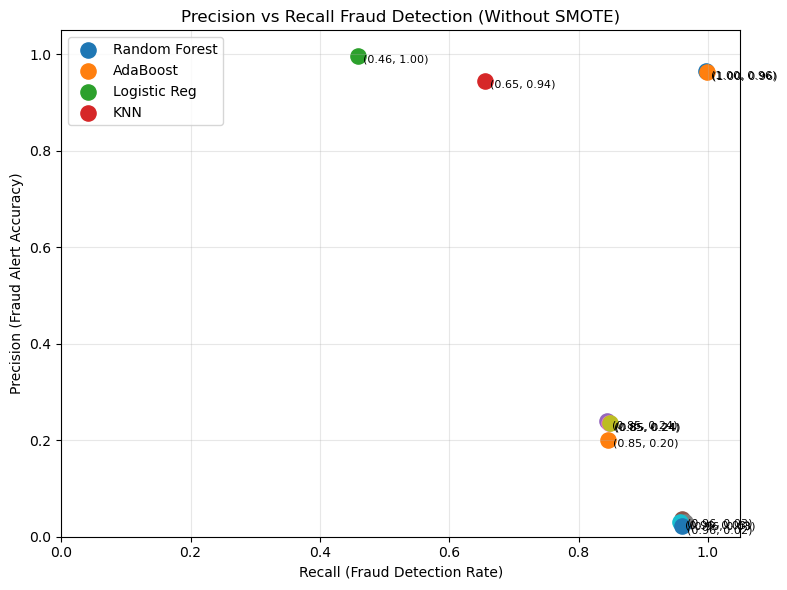

In [74]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

seen = set()

for _, row in results.iterrows():
    # Apply jitter
    x = row["Recall"] + np.random.uniform(-0.005, 0.005)
    y = row["Precision"] + np.random.uniform(-0.005, 0.005)

    label = row["Model"] if row["Model"] not in seen else None
    seen.add(row["Model"])

    plt.scatter(x, y, s=120, label=label)

    # 🔢 Add numeric annotation
    plt.text(
        x + 0.008,
        y - 0.015,
        f"({row['Recall']:.2f}, {row['Precision']:.2f})",
        fontsize=8
    )

plt.title("Precision vs Recall Fraud Detection (Without SMOTE)")
plt.xlabel("Recall (Fraud Detection Rate)")
plt.ylabel("Precision (Fraud Alert Accuracy)")
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("../assets/charts/model-performance-without-smote-precision-recall.png", dpi=300)
plt.show()

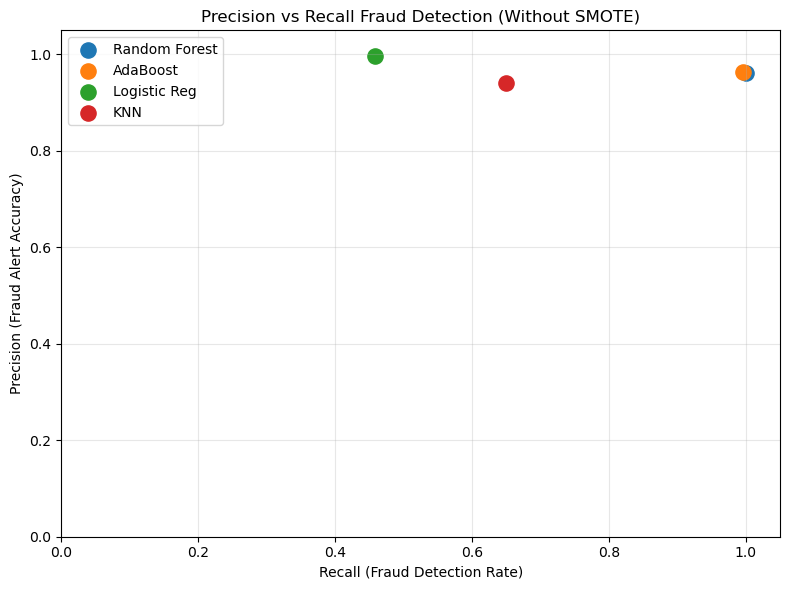

In [55]:
# Plotting Precision vs Recall for each model (without SMOTE)

plt.figure(figsize=(8, 6))

# To prevent overlapping points in the scatter plot, we can add a small random jitter to the precision and recall values. 
# This will help to visually separate points that have similar or identical precision and recall scores.
seen = set()

# Add small random jitter to points to prevent overlap
for _, row in results.iterrows():
    x = row["Recall"] + np.random.uniform(-0.005, 0.005)
    y = row["Precision"] + np.random.uniform(-0.005, 0.005)

    label = row["Model"] if row["Model"] not in seen else None
    seen.add(row["Model"])

    plt.scatter(x, y, s=120, label=label)

plt.title("Precision vs Recall Fraud Detection (Without SMOTE)")
plt.xlabel("Recall (Fraud Detection Rate)")
plt.ylabel("Precision (Fraud Alert Accuracy)")
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
plt.savefig("../assets/charts/model-performance-without-smote-precision-recall.png", dpi=300)
plt.show()

In [ ]:
rf_row = extract_fraud_metrics("Random Forest", y_test, y_pred, workflow="No SMOTE")
ada_row = extract_fraud_metrics("AdaBoost", y_test, ada_y_pred, workflow="No SMOTE")
log_row = extract_fraud_metrics("Logistic Reg.", y_test, log_y_pred, workflow="No SMOTE")
knn_row = extract_fraud_metrics("KNN", y_test, knn_y_pred, workflow="No SMOTE")

results = pd.DataFrame([rf_row, ada_row, log_row, knn_row])
print(results)


### Output of Evaluation Metrics and Best Parameters of Log-Normalized and Dummy Encoding Dataset With Standard Scalar, and Wtihout Using SMOTE

🔥 Training and tuning: Random Forest

✅ Best Parameters for Random Forest:
```
 {'n_estimators': 100, 
 'min_samples_split': 2, 
 'max_features': 'log2',
 'max_depth': 25, 
 'criterion': 
 'entropy'}
 ```
 ```
📊 Confusion Matrix:
 [[19973     1]
 [   10    16]]
 ```

📋 Classification Report:
```
               precision    recall  f1-score   support

           0      0.999     1.000     1.000     19974
           1      0.941     0.615     0.744        26
```
---

🔥 Training and tuning: AdaBoost
✅ Best Parameters for AdaBoost:
 {'n_estimators': 50, 'learning_rate': 0.5, 'estimator__min_samples_split': 5, 'estimator__min_samples_leaf': 1, 'estimator__max_depth': 2}
📊 Confusion Matrix:
 [[19974     0]
 [   17     9]]

📋 Classification Report:
               precision    recall  f1-score   support

           0      0.999     1.000     1.000     19974
           1      1.000     0.346     0.514        26

    accuracy                          0.999     20000
   macro avg      1.000     0.673     0.757     20000
weighted avg      0.999     0.999     0.999     20000

---

🔥 Training and tuning: Logistic Regression

✅ Best Parameters for Logistic Regression:
```
 {'solver': 'saga', 
 'penalty': 'l1',
 'max_iter': 1000, 
 'C': np.float64(10.0)}
```
```
📊 Confusion Matrix:
 [[19974     0]
 [   14    12]]
```

📋 Classification Report:
```
               precision    recall  f1-score   support

           0      0.999     1.000     1.000     19974
           1      1.000     0.462     0.632        26
```
---

🔥 Training and tuning: K-Nearest Neighbors

✅ Best Parameters for K-Nearest Neighbors:
```
{'weights': 'distance', 
'p': 2, 'n_neighbors': 7, 
'leaf_size': 30, 
'algorithm': 'auto'}
```
```
📊 Confusion Matrix:
 - [[19973    1]
 - [ 12      14]]
```

📋 Classification Report:
```
               precision    recall  f1-score   support

           0      0.999     1.000     1.000     19974
           1      0.933     0.538     0.683        26
```
---
---

### Output of Evaluation Metrics and Best Parameters of Log Normalize and Dummy Encoded Transactions using Standard Scalar, and Wtihout Using SMOTE


🔥 Training and tuning: Random Forest
```
✅ Best Parameters for Random Forest:
 {'n_estimators': 400, 
 'min_samples_split': 5, 
 'max_features': 'log2', 
 'max_depth': 35, 
 'criterion': 'gini'}
```
```
📊 Confusion Matrix:
 [[19973     1]
 [    8    18]]
```

📋 Classification Report:
```
               precision    recall  f1-score   support

           0      1.000     1.000     1.000     19974
           1      0.947     0.692     0.800        26

    accuracy                          1.000     20000
```

🔥 Training and tuning: AdaBoost
```
✅ Best Parameters for AdaBoost:
 {'n_estimators': 50, 
 'learning_rate': 0.1, 
 'estimator__min_samples_split': 2, 
 'estimator__min_samples_leaf': 1, '
 estimator__max_depth': 3} 
 ```
 ```
📊 Confusion Matrix:
 [[19973     1]
 [    9    17]]
```

📋 Classification Report:
```
               precision    recall  f1-score   support

           0      1.000     1.000     1.000     19974
           1      0.944     0.654     0.773        26

    accuracy                          1.000     20000
```

🔥 Training and tuning: Logistic Regression
```
✅ Best Parameters for Logistic Regression:
 {'solver': 'saga',
 'penalty': 'l1',
 'max_iter': 1000, 
 'C': np.float64(10.0)}
```
```
📊 Confusion Matrix:
 [[19973     1]
 [   12    14]]
```

📋 Classification Report:
```
               precision    recall  f1-score   support

           0      0.999     1.000     1.000     19974
           1      0.933     0.538     0.683        26

    accuracy                          0.999     20000
```

🔥 Training and tuning: K-Nearest Neighbors
```
✅ Best Parameters for K-Nearest Neighbors:
 {'weights': 'distance',
 'p': 1, 
 'n_neighbors': 7, 
 'leaf_size': 30, 
 'algorithm': 'auto'}
```
📊 Confusion Matrix:
 [[19972     2]
 [    9    17]]
```

📋 Classification Report:
```
               precision    recall  f1-score   support

           0      1.000     1.000     1.000     19974
           1      0.895     0.654     0.756        26

    accuracy                          0.999     20000
```



In [ ]:
# With SMOTE
# Step 1: Separate features (X) and target (y)
X = df_log_dummy_encode_transacts.drop(columns=['isFraud'])  
y = df_log_dummy_encode_transacts['isFraud']                 

# Step 1.2: Split into training and testing sets
# Use stratify=y to keep the fraud/non-fraud ratio consistent, but I think could be redundant when using SMOTE??
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [68]:
df_log_dummy_encode_transacts

,isFraud,CASH_OUT,DEBIT,PAYMENT,TRANSFER,amount_log,oldbalanceOrig_log,newbalanceOrig_log,oldbalanceDest_log,newbalanceDest_log
0,0,False,False,False,False,10.608846,11.522173,11.859486,12.400281,12.515597
1,0,True,False,False,False,12.766230,8.528529,0.000000,8.457159,12.779584
2,0,False,False,True,False,7.707894,7.855409,5.871554,0.000000,0.000000
3,0,False,False,False,False,12.043679,14.555915,14.633881,14.796901,14.866930
4,0,False,False,False,False,12.473167,14.611048,14.722504,13.109396,12.355899
...,...,...,...,...,...,...,...,...,...,...
99995,1,False,False,False,True,12.774484,12.774484,0.000000,0.000000,0.000000
99996,1,True,False,False,False,12.799063,12.799063,0.000000,12.848402,13.517183
99997,1,False,False,False,True,12.862446,12.862446,0.000000,0.000000,0.000000
99998,1,True,False,False,False,13.689961,13.689961,0.000000,9.012266,13.699217


In [69]:
# Step 2: Apply SMOTE to training data only
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

# Step 3: Scale features after SMOTE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

# Step 4: Show class balance and test skew
print("✅ SMOTE applied.")
print("📊 Class balance after SMOTE:\n", y_resampled.value_counts())
print("\n📉 y_test distribution:\n", y_test.value_counts())

✅ SMOTE applied.
📊 Class balance after SMOTE:
 isFraud
0    79896
1    79896
Name: count, dtype: int64

📉 y_test distribution:
 isFraud
0    19974
1       26
Name: count, dtype: int64


### 2) Search for best hyperparameters
Use tools like GridSearchCV, RandomizedSearchCV, or model-specific tuning functions to find the best hyperparameters for your first model.

In [70]:
# Step 6: hyperparameter Search Grids
# With SMOTE 
param_grids = {
    "Random Forest": {
        "n_estimators": [100, 200, 400],                # Number of trees in the forest
        "criterion": ["gini", "entropy", "log_loss"],   # Function to measure the quality of a split
        "max_depth": range(10, 55, 5),                  # Maximum depth of each tree
        "max_features": ["sqrt", "log2"],               # Number of features to consider at each split
        "min_samples_split": [2, 5, 20]                 # Minimum number of samples to split an internal node
    },
    "AdaBoost": {
        "n_estimators": [50, 100, 200],                 # Number of boosting rounds
        "learning_rate": [0.01, 0.1, 0.5, 1.0],         # Shrinks the contribution of each classifier
        "estimator__max_depth": [1, 2, 3],              # Controls weak learner complexity
        "estimator__min_samples_split": [2, 5, 10],     # Regularization
        "estimator__min_samples_leaf": [1, 2, 4]        # Minimum samples required at a leaf node
    },
    "Logistic Reg": {
        "C": np.logspace(-3, 3, 7),                     # Inverse of regularization strength
        "penalty": ["l1", "l2"],                        # Type of regularization to apply
        "solver": ["saga"],                             # Optimizer that supports L1/L2 with large data
        "max_iter": [500, 1000, 1500],                  # Max number of iterations for convergence
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 11],                   # Number of neighbors to use for prediction
        "weights": ["uniform", "distance"],             # Uniform: equal weights, Distance: closer = more weight
        "p": [1, 2],                                     # Distance metric: 1 = Manhattan, 2 = Euclidean
        "leaf_size": [20, 30, 50],                      # Leaf size for tree-based algorithms
        "algorithm": ["auto"]                           # Algorithm used to compute nearest neighbors
    }
}


In [71]:

def extract_fraud_metrics(model_name, y_true, y_pred, workflow="SMOTE"):
    """ Extract fraud-class (class=1) precision, recall, and F1 from predictions.
    Args:
        model_name (str): Name of the model (e.g., "Random Forest")
        y_true (array-like): True labels
        y_pred (array-like): Predicted labels
        workflow (str): Description of the workflow (e.g., "No SMOTE" or "SMOTE")
    Returns:
        dict: A dictionary containing model name, workflow, precision, recall, F1-score, support, and confusion matrix counts.
    """
    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    return {
        "Model": model_name,
        "Workflow": workflow,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1": report["1"]["f1-score"],
        "Support": report["1"]["support"],
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
    }
    

### 3) Model Training

Select the model with best hyperparameters and generate predictions on your test set. Evaluate your models accuracy, precision, recall, and sensitivity.  

In [72]:
# Step 6: Define classifiers for training
# With SMOTE
models = {
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "AdaBoost": AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42),
    "Logistic Reg": LogisticRegression(solver='saga', class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier()
}

# Store best models 
best_models = {}

# Select models for training and tuning
for name, model in models.items():
    print(f"\n🔥 Training and tuning: {name}")
    
    param_grid = param_grids[name] # Select which param to use in randomized search
    
    random_search = RandomizedSearchCV(
        model,
        param_distributions=param_grid,
        #n_iter=10,      # Tuning param
        cv=5,
        scoring='f1',    # Scoring param, maybe I can also try 'roc_auc'??
        random_state=42,
        n_jobs=-1        # Number of CPU-Cores param 
    )
    
    # Fit to training data
    random_search.fit(X_train_scaled, y_resampled)
    
    # Save the best model
    best_models[name] = random_search.best_estimator_

    # Predict on test set using the best model
    yhat = best_models[name].predict(X_test_scaled)

    # Evaluate
    cm = confusion_matrix(y_test, yhat)
    report = classification_report(y_test, yhat, digits=3, zero_division=0)
    auc = roc_auc_score(y_test, yhat)
    
    print(f"✅ Best Parameters for {name}:\n", random_search.best_params_)
    print("📊 Confusion Matrix:\n", cm)
    print("📋 Classification Report:\n", report)
    print(f"🎯 ROC-AUC Score: {auc:.4f}")
    
    # Extract fraud-class metrics for later plotting/table output
    row = extract_fraud_metrics(
        model_name=name,
        y_true=y_test,
        y_pred=yhat,
        workflow="No SMOTE"
    )
    results_rows.append(row)


🔥 Training and tuning: Random Forest
✅ Best Parameters for Random Forest:
 {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 35, 'criterion': 'entropy'}
📊 Confusion Matrix:
 [[19904    70]
 [    4    22]]
📋 Classification Report:
               precision    recall  f1-score   support

           0      1.000     0.996     0.998     19974
           1      0.239     0.846     0.373        26

    accuracy                          0.996     20000
   macro avg      0.619     0.921     0.686     20000
weighted avg      0.999     0.996     0.997     20000

🎯 ROC-AUC Score: 0.9213

🔥 Training and tuning: AdaBoost
✅ Best Parameters for AdaBoost:
 {'n_estimators': 50, 'learning_rate': 0.5, 'estimator__min_samples_split': 5, 'estimator__min_samples_leaf': 1, 'estimator__max_depth': 2}
📊 Confusion Matrix:
 [[19265   709]
 [    1    25]]
📋 Classification Report:
               precision    recall  f1-score   support

           0      1.000     0.965     0.982   

c:\Users\oneps\anaconda3\envs\ml-hands\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


✅ Best Parameters for Logistic Reg:
 {'solver': 'saga', 'penalty': 'l2', 'max_iter': 1000, 'C': np.float64(1000.0)}
📊 Confusion Matrix:
 [[18909  1065]
 [    1    25]]
📋 Classification Report:
               precision    recall  f1-score   support

           0      1.000     0.947     0.973     19974
           1      0.023     0.962     0.045        26

    accuracy                          0.947     20000
   macro avg      0.511     0.954     0.509     20000
weighted avg      0.999     0.947     0.971     20000

🎯 ROC-AUC Score: 0.9541

🔥 Training and tuning: KNN
✅ Best Parameters for KNN:
 {'weights': 'distance', 'p': 2, 'n_neighbors': 3, 'leaf_size': 30, 'algorithm': 'auto'}
📊 Confusion Matrix:
 [[19888    86]
 [    4    22]]
📋 Classification Report:
               precision    recall  f1-score   support

           0      1.000     0.996     0.998     19974
           1      0.204     0.846     0.328        26

    accuracy                          0.996     20000
   macro avg   

## Training and Evaluation Metrics Using Three Models from baseline.csv (no transformations--scaling, etc.)
💥 Training and evaluating: Random Forest

```
📊 Confusion Matrix:
 [[39820   128]  → True Negatives / False Positives
 [   11    41]]  → False Negatives / True Positives
 ```
📄 Classification Report:
```
               precision    recall  f1-score   support

           0      1.000     0.997     0.998     39948
           1      0.243     0.788     0.371        52

    accuracy                          0.997     40000
```

💥 Training and evaluating: AdaBoost
```
📊 Confusion Matrix:
 [[37111  2837] → True Negatives / False Positives
 [    1    51]] → False Negatives / True Positives
```
📄 Classification Report:
```
               precision    recall  f1-score   support

           0      1.000     0.929     0.963     39948
           1      0.018     0.981     0.035        52

    accuracy                          0.929     40000
```
   
💥 Training and evaluating: Logistic Regression
```
📊 Confusion Matrix:
 [[39049   899]
 [    5    47]]
 ```
 ```
📄 Classification Report:
               precision    recall  f1-score   support

           0      1.000     0.977     0.989     39948
           1      0.050     0.904     0.094        52

    accuracy                          0.977     40000
```

In [73]:
# dataframe of results
results = pd.DataFrame(results_rows)
display(results)

,Model,Workflow,Precision,Recall,F1,Support,TP,FP,FN,TN
0,Random Forest,No SMOTE,0.962963,1.000000,0.981132,26.0,26,1,0,19973
1,AdaBoost,No SMOTE,0.962963,1.000000,0.981132,26.0,26,1,0,19973
2,Logistic Reg,No SMOTE,1.000000,0.461538,0.631579,26.0,12,0,14,19974
3,KNN,No SMOTE,0.944444,0.653846,0.772727,26.0,17,1,9,19973
4,Random Forest,No SMOTE,0.239130,0.846154,0.372881,26.0,22,70,4,19904
5,AdaBoost,No SMOTE,0.034060,0.961538,0.065789,26.0,25,709,1,19265
6,Random Forest,No SMOTE,0.239130,0.846154,0.372881,26.0,22,70,4,19904
7,AdaBoost,No SMOTE,0.034060,0.961538,0.065789,26.0,25,709,1,19265
8,Random Forest,No SMOTE,0.239130,0.846154,0.372881,26.0,22,70,4,19904
9,AdaBoost,No SMOTE,0.034060,0.961538,0.065789,26.0,25,709,1,19265


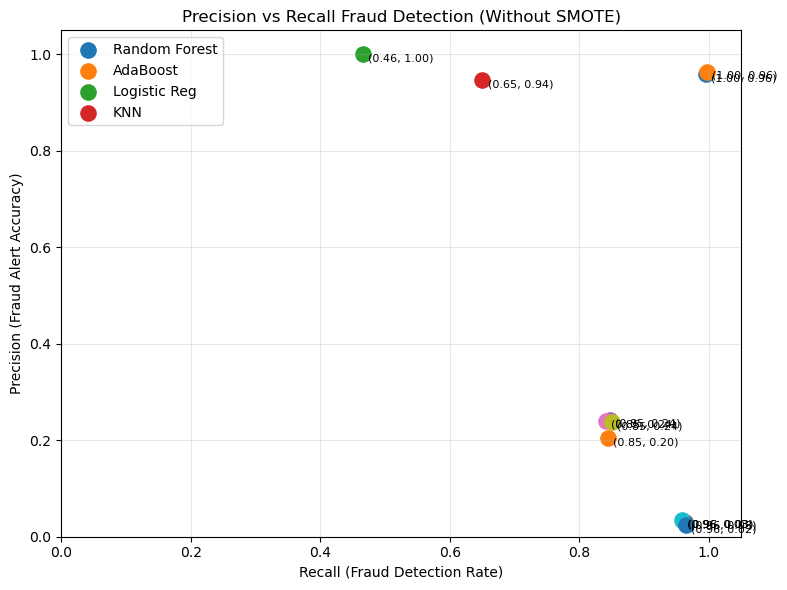

In [ ]:
# Plotting Precision vs Recall for each model (without SMOTE)

plt.figure(figsize=(8, 6))

# To prevent overlapping points in the scatter plot, we can add a small random jitter to the precision and recall values. 
# This will help to visually separate points that have similar or identical precision and recall scores.
seen = set()

# Add small random jitter to points to prevent overlap
for _, row in results.iterrows():
    x = row["Recall"] + np.random.uniform(-0.005, 0.005)
    y = row["Precision"] + np.random.uniform(-0.005, 0.005)

    label = row["Model"] if row["Model"] not in seen else None
    seen.add(row["Model"])

    plt.scatter(x, y, s=120, label=label)
    
     # 🔢 Add numeric annotation
    plt.text(
        x + 0.008,
        y - 0.015,
        f"({row['Recall']:.2f}, {row['Precision']:.2f})",
        fontsize=8
    )

plt.title("Precision vs Recall Fraud Detection (With SMOTE)")
plt.xlabel("Recall (Fraud Detection Rate)")
plt.ylabel("Precision (Fraud Alert Accuracy)")
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
plt.savefig("../assets/charts/model-performance-without-smote-precision-recall.png", dpi=300)
plt.show()

## Second Model

Create a second machine learning object and rerun steps (2) & (3) on this model. Compare accuracy metrics between these two models. Which handles the class imbalance more effectively?

Create as many code-blocks as needed.

In [ ]:
# There are four models in the dictionary above...

### (Bonus/Optional) Third Model

Create a third machine learning model and rerun steps (2) & (3) on this model. Which model has the best predictive capabilities? 

Create as many code-blocks as needed.


The best model so far is, ***Random Forest** with the following configuration and results:

### Random Forest 

✅ Best Parameters for Random Forest:
```
 {'n_estimators': 400, 
 'min_samples_split': 5,
  'max_features': 'log2', 
  'max_depth': 35, 'criterion': 
  'gini'}
```
```
📊 Confusion Matrix:
 [[19973     1] → True Negatives / False Positives
 [    8    18]] → False Negatives / True Positives
 ```

📋 Classification Report:
| Class | Precision | Recall | F1-Score | Support |
  |-------|-----------|--------|----------|---------|
  | 0     | 1.00      | 1.00   | 1.00     | 19974   |
  | 1     | 0.95      | 0.69   | 0.80     | 26      |


- This shows that Random Forest does **well** at identifying non-fraud, and achieves very strong *F1-Score** for fraud despite class imbalance. I'll continue to tune model parameters, use various data transform datasets, etc., in order to achieve even better precision-recall trade-off.
- The dataset used: df_log_dummy_encode_transacts
   - consisting of **log and dummy encoding transaction** columns only. 
   - Done without the use of SMOTE
   - Done with Standard Scalar (mean=0, variance=1)

---

**Support Vector Machine using MinMaxScalar()** 

- **Best Parameters for SVC**
  ```python
  {
    'C': np.logspace(-2, 2, 5),            
    'kernel': ['rbf', 'sigmoid'],          
    'gamma': ['scale', 'auto'] 
  }
  ```

- **Confusion Matrix**:
  ```
  [[19974     1] → True Negatives / False Positives
   [   9    17]] → False Negatives / True Positives
  ```

- **Classification Report**:

  | Class | Precision | Recall | F1-Score | Support |
  |-------|-----------|--------|----------|---------|
  | 0     | 1.00      | 1.00   | 1.00     | 19974   |
  | 1     | 0.94      | 0.65   | 0.77     | 26      |

  - This shows that Support Vector Machine performs **well** at identifying non-fraud, and achieves strong *F1-Score** for fraud despite class imbalance. I'll continue to tune model parameters, use various data transform datasets, etc., in order to achieve even better precision-recall trade-off.
- The dataset used: log_transacts
   - Consisting of **log-transformed** columns only. 
   - Done without using SMOTE 
   - Done using MinMaxScalar

In [14]:
# Step 2: Separate features and target
X = df_log_dummy_encode_transacts.drop(columns=['isFraud'])  # All features except target
y = df_log_dummy_encode_transacts['isFraud']                 # Target variable

# Step 3: Split into training and testing sets
# Use stratify=y to keep the fraud/non-fraud ratio consistent, but could be reduntdant when using SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
# Without SMOTE
# Initialize MinMaxScaler to scale data to [0, 1]
scaler = MinMaxScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define hyperparameter grid for SVC
svc_param_grid = {
    'C': np.logspace(-2, 2, 5),
    'kernel': ['rbf', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

# Initialize the SVC model
svc = SVC(max_iter=10000, random_state=42)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=svc,
    param_distributions=svc_param_grid,
    scoring='f1',
    cv=5,
    n_iter=10,
    n_jobs=-1,
    random_state=42
)

# Fit the model on the scaled training data
random_search.fit(X_train_scaled, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(max_iter=...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.e-02...e+01, 1.e+02]), 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'sigmoid']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default v

In [16]:
# best model after tuning
best_svc = random_search.best_estimator_

# scaled test data for predictions
yhat = best_svc.predict(X_test_scaled)

confusion = confusion_matrix(y_test, yhat)
class_report = classification_report(y_test, yhat)

print("✅ Confusion Matrix:\n", confusion)
print("\n✅ Classification Report:\n", class_report)

✅ Confusion Matrix:
 [[19973     1]
 [    9    17]]

✅ Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     19974
           1       0.94      0.65      0.77        26

    accuracy                           1.00     20000
   macro avg       0.97      0.83      0.89     20000
weighted avg       1.00      1.00      1.00     20000



In [18]:
# With SMOTE 
# Apply SMOTE to training data only
# ✅ KMeansSMOTE is faster + cluster-aware
kmeans = KMeans(n_clusters=15, random_state=42)
sm = KMeansSMOTE(random_state=42, n_jobs=-1, cluster_balance_threshold=0.001, kmeans_estimator=kmeans)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

# Initialize MinMaxScaler to scale data to [0, 1]
scaler = MinMaxScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)# Fit scaler on training data to prevent data leakage/peeking

# Print balanced classes
# Show class balance and test skew
print("✅ SMOTE applied.")
print("📊 Class balance after SMOTE:\n", y_resampled.value_counts())
print("\n📉 y_test distribution:\n", y_test.value_counts())

c:\Users\oneps\anaconda3\envs\ml-hands\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


✅ SMOTE applied.
📊 Class balance after SMOTE:
 isFraud
1    79899
0    79896
Name: count, dtype: int64

📉 y_test distribution:
 isFraud
0    19974
1       26
Name: count, dtype: int64


In [19]:
# Define hyperparameter grid for SVC
# With SMOTE
svc_param_grid = {
    'C': np.logspace(-2, 2, 5),
    'kernel': ['rbf', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

# Initialize the SVC model
svc = SVC(max_iter=10000, random_state=42)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=svc,
    param_distributions=svc_param_grid,
    scoring='f1',
    cv=5,
    n_iter=10,
    n_jobs=-1,
    random_state=42
)

# Fit the model on the scaled training data
random_search.fit(X_train_scaled, y_resampled)vrr


c:\Users\oneps\anaconda3\envs\ml-hands\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(max_iter=...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.e-02...e+01, 1.e+02]), 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'sigmoid']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default v

In [20]:
# best model after tuning
best_svc = random_search.best_estimator_

# scaled test data for predictions
yhat = best_svc.predict(X_test_scaled)

confusion = confusion_matrix(y_test, yhat)
class_report = classification_report(y_test, yhat)

print("✅ Confusion Matrix:\n", confusion)
print("\n✅ Classification Report:\n", class_report)

✅ Confusion Matrix:
 [[19096   878]
 [    0    26]]

✅ Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98     19974
           1       0.03      1.00      0.06        26

    accuracy                           0.96     20000
   macro avg       0.51      0.98      0.52     20000
weighted avg       1.00      0.96      0.98     20000



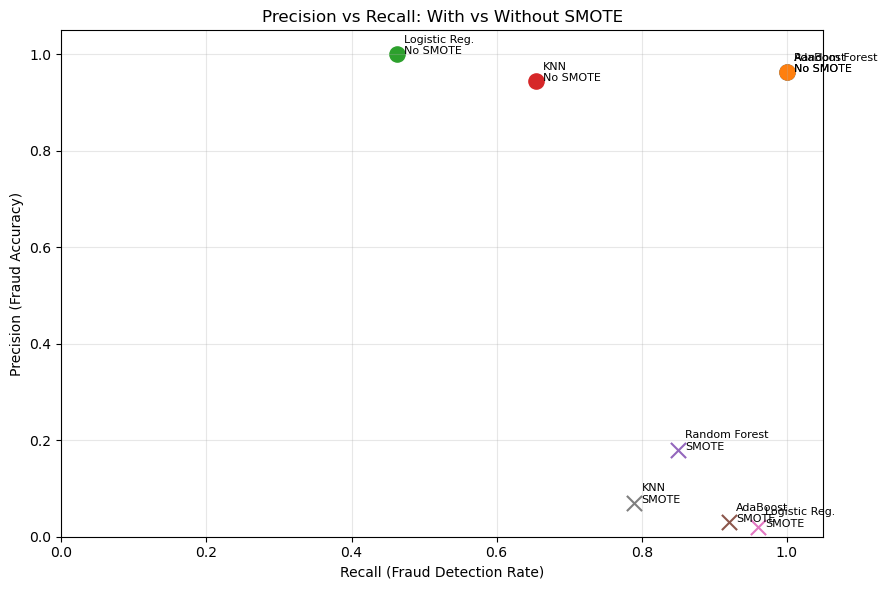

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame([
    # WITHOUT SMOTE
    {"Model": "Random Forest", "Workflow": "No SMOTE", "Precision": 0.963, "Recall": 1.000},
    {"Model": "AdaBoost",      "Workflow": "No SMOTE", "Precision": 0.963, "Recall": 1.000},
    {"Model": "Logistic Reg.", "Workflow": "No SMOTE", "Precision": 1.000, "Recall": 0.462},
    {"Model": "KNN",           "Workflow": "No SMOTE", "Precision": 0.944, "Recall": 0.654},

    # WITH SMOTE 
    {"Model": "Random Forest", "Workflow": "SMOTE", "Precision": 0.18, "Recall": 0.85},
    {"Model": "AdaBoost",      "Workflow": "SMOTE", "Precision": 0.03, "Recall": 0.92},
    {"Model": "Logistic Reg.", "Workflow": "SMOTE", "Precision": 0.02, "Recall": 0.96},
    {"Model": "KNN",           "Workflow": "SMOTE", "Precision": 0.07, "Recall": 0.79},
])

plt.figure(figsize=(9, 6))

for _, row in results.iterrows():
    if row["Workflow"] == "No SMOTE":
        marker = "o"
    else:
        marker = "x"

    plt.scatter(row["Recall"], row["Precision"], s=120, marker=marker)

    plt.text(row["Recall"] + 0.01,
             row["Precision"],
             f'{row["Model"]}\n{row["Workflow"]}',
             fontsize=8)

plt.title("Precision vs Recall: With vs Without SMOTE")
plt.xlabel("Recall (Fraud Detection Rate)")
plt.ylabel("Precision (Fraud Accuracy)")

plt.xlim(0, 1.05)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../assets/charts/model-performance-smote-vs-no-smote.png", dpi=300)
plt.show()